# 02. Model Baselines and Comparison

Цель ноутбука:
- воспроизвести базовый пайплайн обучения;
- сравнить несколько моделей;
- получить таблицу метрик для отчета.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "hotel_bookings.csv").exists():
    if (PROJECT_ROOT.parent / "data" / "hotel_bookings.csv").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from src.data import load_dataset, split_features_target
from src.features import build_preprocessor
from src.models import build_candidate_models

sns.set_theme(style="whitegrid")
DATA_PATH = PROJECT_ROOT / "data" / "hotel_bookings.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("EXISTS:", DATA_PATH.exists())

PROJECT_ROOT: f:\MIREA\ArtificialIntelligenceEngineering\project
DATA_PATH: f:\MIREA\ArtificialIntelligenceEngineering\project\data\hotel_bookings.csv
EXISTS: True


In [2]:
df = load_dataset(DATA_PATH)
x, y = split_features_target(df)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(x_train.shape, x_test.shape)

(89542, 20) (29848, 20)


In [3]:
preprocessor = build_preprocessor()
models = build_candidate_models(random_state=42)
results = []

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )
    pipeline.fit(x_train, y_train)
    probabilities = pipeline.predict_proba(x_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results.append(
        {
            "model": model_name,
            "roc_auc": roc_auc_score(y_test, probabilities),
            "f1": f1_score(y_test, predictions),
            "pr_auc": average_precision_score(y_test, probabilities),
        }
    )

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,model,roc_auc,f1,pr_auc
2,mlp_classifier,0.891724,0.734913,0.863743
1,random_forest,0.876586,0.686122,0.848373
0,logistic_regression,0.850216,0.699365,0.823868


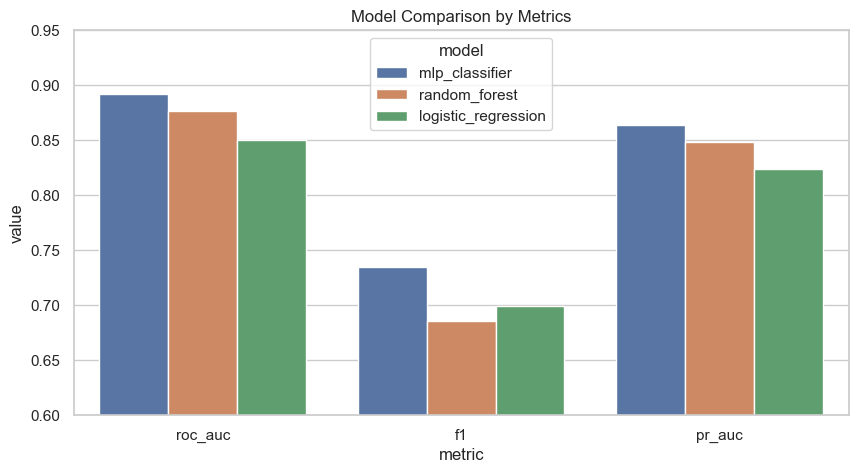

In [4]:
melted = results_df.melt(id_vars="model", var_name="metric", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x="metric", y="value", hue="model")
plt.title("Model Comparison by Metrics")
plt.ylim(0.6, 0.95)
plt.show()

## Выводы

1. `LogisticRegression` задает интерпретируемый и достойный baseline.
2. `RandomForest` улучшает ранжирование по сравнению с линейной моделью, но не выигрывает по `F1`.
3. `MLPClassifier` показывает лучший суммарный результат и поэтому может быть выбран финальной моделью для сервиса.
4. Для отчета и защиты удобно показывать именно таблицу метрик и barplot из этого ноутбука.